# Tapered webbed ellipse -- RM shell vs 3-D solid

Homogenizes the equivalent-beam **Timoshenko $6\times6$** ($C^b$) of the tapered webbed ellipse
with a single **6-DOF independent-$\omega_3$ Reissner--Mindlin shell**, for both the
**boundary ring** and the **tapered segment**, at thin ($t/R=0.02$) and thick ($t/R=0.20$)
walls, single $[-45^\circ]$ ply, and compares against a conforming 3-D FEniCS solid.

A blade-like multi-cell ellipse with three internal shear webs -- the most demanding case in the paper.

Transverse-shear scheme (6-DOF everywhere): the tapered segment uses **full integration** at
every thickness (locking-free; MITC would alias the drilling on flat walls); the boundary ring
uses a $\gamma_{23}$-tie on the thin wall and full integration on the thick wall.

This notebook runs `examples/RM_taper/ellipse.py` inline.

In [1]:
%matplotlib inline
import os, sys, numpy as np
def _root(d):
    d = os.path.abspath(d)
    while d != os.path.dirname(d):
        if os.path.exists(os.path.join(d, "pyproject.toml")): return d
        d = os.path.dirname(d)
    return os.getcwd()
CC = _root(os.getcwd())
sys.path.insert(0, os.path.join(CC, "examples", "RM_taper"))
sys.path.insert(0, os.path.join(CC, "opensg_jax"))
import _rm_common as rm
np.set_printoptions(precision=4, suppress=True, linewidth=140)
MESH = os.path.join(CC, "examples", "data", "rm_taper_ellipse", "meshes")
REF  = np.load(os.path.join(CC, "examples", "data", "benchmark", "ellipse_solid_m45.npz"))
RES  = os.path.join(CC, "docs", "tutorials", "_rmout"); os.makedirs(RES, exist_ok=True)

## Mesh and material orientation

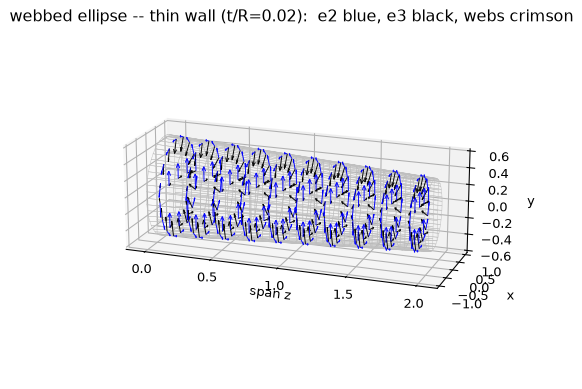

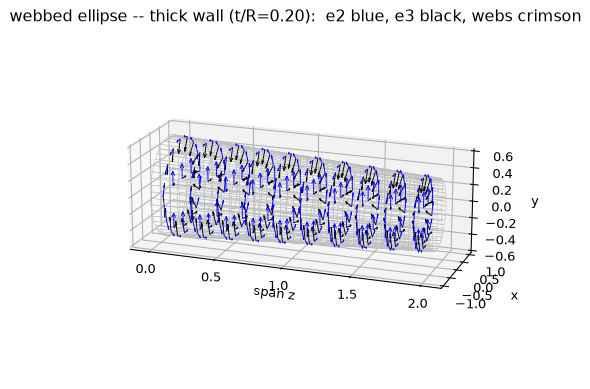

In [2]:
from IPython.display import Image, display
for r in ("thin", "thick"):
    tg = "{r}_m45".replace("{r}", r)
    ttl = "webbed ellipse -- %s wall (t/R=%s):  e2 blue, e3 black, webs crimson" % (r, "0.02" if r == "thin" else "0.20")
    png = rm.render_orientation(MESH, tg, RES, title=ttl)
    display(Image(filename=png))

## Timoshenko $6\times6$ -- boundary ring and tapered segment

In [3]:
def show(label, So, Sh, shear):
    So = 0.5 * (So + So.T); Sh = 0.5 * (Sh + Sh.T)
    print("\n" + label + "   [6-DOF RM shell, shear=%s]" % shear)
    print("RM shell Timoshenko 6x6  (x1e9):")
    print(Sh / 1e9)
    e = 100 * (np.diag(Sh) - np.diag(So)) / np.diag(So)
    print("diagonal %err vs 3-D solid [EA, GA2, GA3, GJ, EI2, EI3]:", np.round(e, 1))

for r, tR in (("thin", 0.02), ("thick", 0.20)):
    tg = "{r}_m45".replace("{r}", r)
    print("=" * 72)
    print("webbed ellipse -- %s wall (t/R = %.2f)" % (r.upper(), tR))
    sb = rm.shear_for("boundary", tR); st = rm.shear_for("taper", tR)
    Cb = rm.solve_boundary(MESH, tg, RES, sb); show("BOUNDARY ring", REF[tg + "_L"], Cb, sb)
    Ct = rm.solve_taper(MESH, tg, RES, st);    show("TAPERED segment", REF[tg + "_seg"], Ct, st)

webbed ellipse -- THIN wall (t/R = 0.02)



BOUNDARY ring   [6-DOF RM shell, shear=mitc4_g23]
RM shell Timoshenko 6x6  (x1e9):
[[ 2.048   0.      0.2018 -0.2512  0.     -0.0007]
 [ 0.      0.3158  0.     -0.      0.0861  0.    ]
 [ 0.2018  0.      0.6696  0.0001  0.      0.1193]
 [-0.2512 -0.      0.0001  0.4379 -0.     -0.0167]
 [ 0.      0.0861  0.     -0.      0.3174  0.    ]
 [-0.0007  0.      0.1193 -0.0167  0.      0.6685]]
diagonal %err vs 3-D solid [EA, GA2, GA3, GJ, EI2, EI3]: [  3.4 -16.8   3.3   3.    1.9   4.9]



TAPERED segment   [6-DOF RM shell, shear=full]
RM shell Timoshenko 6x6  (x1e9):
[[ 1.6714 -0.0726  0.2126 -0.1568 -0.0007  0.0129]
 [-0.0726  0.2979 -0.213  -0.0008  0.052  -0.0572]
 [ 0.2126 -0.213   0.6792  0.0014  0.0117  0.1169]
 [-0.1568 -0.0008  0.0014  0.2349 -0.0005 -0.009 ]
 [-0.0007  0.052   0.0117 -0.0005  0.1876 -0.0063]
 [ 0.0129 -0.0572  0.1169 -0.009  -0.0063  0.38  ]]
diagonal %err vs 3-D solid [EA, GA2, GA3, GJ, EI2, EI3]: [ 2.5 -2.5 28.7  0.7  0.5  2.9]
webbed ellipse -- THICK wall (t/R = 0.20)



BOUNDARY ring   [6-DOF RM shell, shear=full]
RM shell Timoshenko 6x6  (x1e9):
[[20.4759 -0.      2.0292 -2.5131  0.     -0.0052]
 [-0.      5.2978  0.      0.      1.4305 -0.    ]
 [ 2.0292  0.      6.9007  0.0473  0.      1.2203]
 [-2.5131  0.      0.0473  4.5645  0.     -0.1763]
 [ 0.      1.4305  0.      0.      3.3593  0.    ]
 [-0.0052 -0.      1.2203 -0.1763  0.      6.7312]]
diagonal %err vs 3-D solid [EA, GA2, GA3, GJ, EI2, EI3]: [13.2 -3.9  5.6  3.7 12.6 10.6]



TAPERED segment   [6-DOF RM shell, shear=full]
RM shell Timoshenko 6x6  (x1e9):
[[16.5743 -0.371   1.7053 -1.5773  0.0419  0.0387]
 [-0.371   3.7913 -0.951  -0.0152  0.8125 -0.4688]
 [ 1.7053 -0.951   5.6994  0.0474  0.304   0.8998]
 [-1.5773 -0.0152  0.0474  2.5006 -0.0051 -0.0981]
 [ 0.0419  0.8125  0.304  -0.0051  1.9877 -0.0577]
 [ 0.0387 -0.4688  0.8998 -0.0981 -0.0577  3.7849]]
diagonal %err vs 3-D solid [EA, GA2, GA3, GJ, EI2, EI3]: [13.4 -4.5 13.9  1.4 12.6  7.9]
